## Faire les figures en un clic !

#### **Import des librairies**

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import numpy as np
import os
import sys

os.environ['DATABASE_FILE'] = "flagdbplante.cfg"
os.environ['DEBUG'] = "False"
os.chdir("/home/crakshay/SUSHI/Work/GBOT/flagv5.0/")

*Je préfère utiliser R pour générer mes figures, et ce notebook est une version "traduite" de tous les scripts R qui servaient à les faire !*

#### **Histogramme général**

In [105]:
resume = pd.read_csv(os.path.abspath("Projet/Rapport/resume.txt"), sep="\t")
resume["Total"] = resume["Common"] + resume["Added"] + resume["Missed"]

percentages = resume[["Common", "Added", "Missed"]].div(resume["Total"], axis=0)

# format long
df = percentages.copy()
df["Species"] = resume["Species"]

df = df.melt(
    id_vars="Species",
    var_name="Category",
    value_name="Value"
)

df["Category"] = df["Category"].replace({
    "Common": "In common",
    "Added": "Added by Helixer",
    "Missed": "Missed by Helixer"
})

species_order = resume.sort_values(by="Common", ascending=False)["Species"]

categories = ["In common", "Added by Helixer", "Missed by Helixer"]

colors = {
    "In common": "#00a3a6",
    "Added by Helixer": "#a2a5a8",
    "Missed by Helixer": "#63003C"
}

pivot = df.pivot(index="Species", columns="Category", values="Value")
pivot = pivot.loc[species_order, categories]

x = range(len(species_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, cat in enumerate(categories):

    bars = ax.bar(
        [pos + (i - 1) * width for pos in x],
        pivot[cat].values * 100,
        width=width,
        label=cat,
        color=colors[cat]
    )

    for bar in bars:
        h = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 0.5,
            f"{h:.1f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_ylabel("Ammount of CDS (%)", fontweight="bold")
ax.set_xticks(list(x))
ax.set_xticklabels(species_order, rotation=30, ha="right")

ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15), ncol=3, frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

#plt.savefig("Projet/Rapport/Figures/figure_CDS_comparisonFS.png",dpi=600,bbox_inches="tight")
plt.show()
plt.close()

os.system(f"Rscript {os.path.abspath("Projet/Rapport/CodesFig/hist.r")}") # Ouais je lâcherai pas R !

ValueError: Index contains duplicate entries, cannot reshape

#### **Analyse des protéines exclusivement Helixer** 

*Mais avant, faisons un point sur les stats concernant Helixer...*

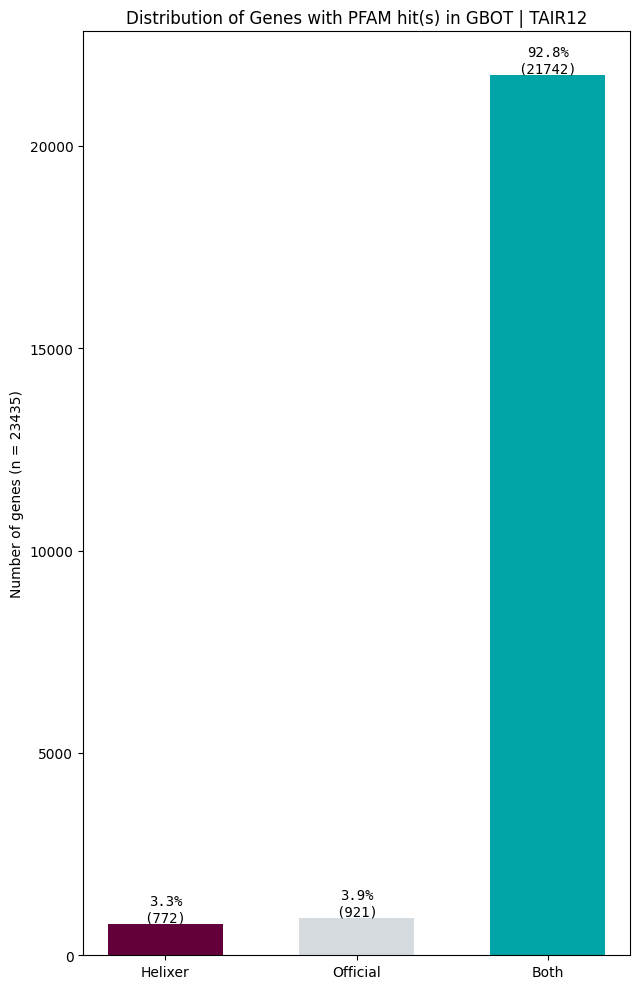

Messages d'avis :
1: Dans grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Identity ≥ 50% | Qcover ≥ 60% | Evalue ≤ 1e-05' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)
2: Dans grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Identity ≥ 50% | Qcover ≥ 60% | Evalue ≤ 1e-05' in 'mbcsToSbcs': >= substituted for ≥ (U+2265)
3: Dans grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for 'Identity ≥ 50% | Qcover ≥ 60% | Evalue ≤ 1e-05' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)


0

In [ ]:
def PFAMNumber(name, save, official, helixer, both, file1, file2, file3):

    save = Path(save)

    summary_df = pd.DataFrame({
        "PFAM": ["Helixer", "Official", "Both"],
        "n": [int(helixer), int(official), int(both)]
    })

    total = summary_df["n"].sum()

    summary_df["freq"] = summary_df["n"] / total

    summary_df["label"] = (
        (summary_df["freq"] * 100)
        .round(1)
        .astype(str)
        + "%\n("
        + summary_df["n"].astype(str)
        + ")"
    )

    colors = {
        "Helixer": "#63003C",
        "Official": "#D6DBDF",
        "Both": "#00a3a6"
    }

    fig, ax = plt.subplots(
        figsize=(6.5, 10)
    )

    bars = ax.bar(
        summary_df["PFAM"],
        summary_df["n"],
        color=[colors[x] for x in summary_df["PFAM"]],
        width=0.6
    )

    for bar, label in zip(bars, summary_df["label"]):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            label,
            ha="center",
            va="bottom",
            fontsize=10,
            family="monospace"
        )

    ax.set_title(
        f"Distribution of Genes with PFAM hit(s) in GBOT | {name}"
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        f"Number of genes (n = {total})"
    )

    plt.tight_layout()

    plt.show()
    plt.close()



# Call de la fonction
from FLAGdbServer.apis.feature import featureDAO 
from Projet.find_differences1 import comparing_annotations
seuil = 50
qcover = 60
name = "TAIR12"
species_id = 34
save_dir = os.path.abspath("Projet/Species/TAIR12/figs/")
added = os.path.abspath("Projet/Species/TAIR12/Stats/Added_Arabidopsis_thaliana_TAIR12.txt")
missed = os.path.abspath("Projet/Species/TAIR12/Stats/Missed_Arabidopsis_thaliana_TAIR12.txt")
common = os.path.abspath("Projet/Species/TAIR12/Stats/Commons_Arabidopsis_thaliana_TAIR12.txt")
file1 = os.path.abspath("Projet/Species/TAIR12/Protein_Analysis_Common.tsv") # Common
file2 = os.path.abspath("Projet/Species/TAIR12/Protein_Analysis_Added.tsv") # Added
file3 = os.path.abspath("Projet/Species/TAIR12/Protein_Analysis_Missed.tsv") # Missed

*Il est temps de faire l'analyse !*

In [ ]:
def protein_analysis_species(name, save, blast_file, pfam_file=None, eggnog_file=None):
    save = Path(save)
    blast_results = pd.read_csv(blast_file, sep="\t")

    # PFAM
    if pfam_file is not None:

        pfam = pd.read_csv(
            pfam_file,
            sep="\t",
            header=None
        )

        commons = blast_results.merge(
            pfam,
            left_on="Gene",
            right_on=1,
            how="inner"
        )

        df_true1 = (
            commons
            .sort_values("Evalue")
            .dropna(subset=["Evalue"])
            .drop_duplicates(subset=["Gene"])
        )

        df_true1.to_csv(
            save / "../BlastAnalysis/FilteredPFAMProteinAnalysis.tsv",
            sep="\t",
            index=False
        )

    # BLAST filtering
    df_sorted = blast_results.sort_values("Evalue")
    df_true = df_sorted.dropna(subset=["Evalue"])

    # EggNOG
    giving_match = pd.DataFrame()

    if eggnog_file is not None:

        eggnog = (
            pd.read_csv(eggnog_file, sep="\t")
            [["query",
              "seed_ortholog",
              "GOs",
              "Description",
              "score",
              "evalue",
              "max_annot_lvl"]]
            .sort_values("evalue")
            .drop_duplicates("query")
        )

        no_match = (
            df_sorted[df_sorted["Evalue"].isna()]
            [["Gene", "CDSLength", "ExonsNb"]]
        )

        eggnog["clean_query"] = (
            eggnog["query"]
            .str.replace(r"_[^_]*$", "", regex=True)
        )

        eggnog = eggnog.drop(columns=["query"])

        giving_match = no_match.merge(
            eggnog,
            left_on="Gene",
            right_on="clean_query",
            how="inner"
        )

        giving_match = giving_match.sort_values("evalue")

        giving_match.to_csv(
            save / "../BlastAnalysis/FilteredEggNogProtein.tsv",
            sep="\t",
            index=False
        )

    # FIGURE
    blast_results["Uniprot"] = blast_results["Evalue"].apply(
        lambda x: "No hit" if pd.isna(x) else "Uniprot Hit"
    )

    total = len(blast_results)
    hit = (blast_results["Uniprot"] == "Uniprot Hit").sum()
    no_hit = (blast_results["Uniprot"] == "No hit").sum()

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(20, 7)
    )

    # PANEL A
    steps = ["Total", "Uniprot hit", "No hit"]
    counts = [total, hit, no_hit]

    colors = [
        "#00a3a6",
        "#63003C",
        "#D6DBDF"
    ]

    ax = axes[0]

    bars = ax.bar(
        steps,
        counts,
        color=colors
    )

    for bar, count in zip(bars, counts):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            count,
            f"({count})",
            ha="center",
            va="bottom"
        )

    ax.set_title(
        "A - Identification of Helixer specific-proteins in Uniprot"
    )
    ax.set_ylabel(
        "Number of Helixer-specific proteins"
    )

    # PANEL B
    ax = axes[1]

    if pfam_file is not None:

        pfam_genes = set(pfam[1])

        blast_results["PFAM"] = blast_results["Gene"].apply(
            lambda x: "Present"
            if x in pfam_genes
            else "Absent"
        )

        dfB = (
            blast_results
            .groupby(["Uniprot", "PFAM"])
            .size()
            .reset_index(name="n")
        )

        pivot = (
            dfB
            .pivot(
                index="Uniprot",
                columns="PFAM",
                values="n"
            )
            .fillna(0)
        )

        bottom = None

        for category, color in zip(
            ["Present", "Absent"],
            ["#63003C", "#D6DBDF"]
        ):

            values = pivot.get(
                category,
                pd.Series(
                    0,
                    index=pivot.index
                )
            )

            ax.bar(
                pivot.index,
                values,
                bottom=bottom,
                label=category,
                color=color
            )

            if bottom is None:
                bottom = values.copy()
            else:
                bottom += values

        ax.legend(title="PFAM Proteins")

        ax.set_title(
            "B - PFAM support across Helixer-specific proteins and UniProt mappings"
        )

    else:
        ax.axis("off")
        ax.set_title("B - PFAM not available")

    # PANEL C
    ax = axes[2]

    if eggnog_file is not None:

        no_match = (
            df_sorted[df_sorted["Evalue"].isna()]
            [["Gene"]]
            .copy()
        )

        recovered = set(giving_match["Gene"])

        no_match["EggNOG"] = no_match["Gene"].apply(
            lambda x:
            "Recovered"
            if x in recovered
            else "Missing"
        )

        dfC = (
            no_match
            .groupby("EggNOG")
            .size()
            .reset_index(name="n")
        )

        colors = {
            "Recovered": "#63003C",
            "Missing": "#D6DBDF"
        }

        bars = ax.bar(
            dfC["EggNOG"],
            dfC["n"],
            color=[
                colors[x]
                for x in dfC["EggNOG"]
            ]
        )

        for bar, count in zip(
            bars,
            dfC["n"]
        ):
            ax.text(
                bar.get_x() + bar.get_width()/2,
                count,
                f"({count}/{len(no_match)})",
                ha="center",
                va="bottom"
            )

        ax.set_title(
            "C - EggNOG annotations for Uniprot unmatched proteins"
        )

    else:
        ax.axis("off")
        ax.set_title("C - EggNOG not available")

    plt.tight_layout()
    plt.show()
    plt.close()

# Call de la fonction
name = 'TAIR12' 
save_dir = os.path.abspath('Projet/Species/TAIR12/figs/' )
blast = os.path.abspath('Projet/Species/TAIR12/Protein_Analysis_Added.tsv') 
pfam = os.path.abspath('Projet/Species/TAIR12/Arabidopsis_thaliana_TAIR12_pfamHelixer.txt')
eggnog = os.path.abspath('Projet/Species/TAIR12/EggNogTAIR12.tabular') 
pident_seuil = 60
#protein_analysis_species(name, save_dir, blast, pfam, eggnog)

# Ou sinon la meilleure version du graphe...
os.system(f"Rscript Projet/Rapport/CodesFig/ProteinAnalysisSpecies.r {name} {save_dir} {pident_seuil} {blast} {pfam} {eggnog}")
#os.system(f"Rscript Projet/Rapport/CodesFig/ProteinAnalysisSpecies.r {name} {save_dir} {pident_seuil} {blast}")

Messages d'avis :
1: Removed 830 rows containing non-finite outside the scale range (`stat_bin()`). 
2: Dans grid.Call.graphics(C_text, as.graphicsAnnot(x$label), x$x, x$y,  :
  for '≤50% identity' in 'mbcsToSbcs': <= substituted for ≤ (U+2264)


0

In [ ]:
from FLAGdbServer.apis.feature import featureDAO                    # Module pour interroger des features
from FLAGdbServer.apis.sequence import sequenceDAO


experts = featureDAO.getAllFeatsForSpecies(34, "CDS")
helixer = featureDAO.getAllFeatsForSpecies(34, "helixer_CDS")
nc_RNA = featureDAO.getAllFeatsForSpecies(34, "ncRNA")
rRNA = featureDAO.getAllFeatsForSpecies(34, "rRNA")
tRNA = featureDAO.getAllFeatsForSpecies(34, "tRNA")
miscRNA = featureDAO.getAllFeatsForSpecies(34, "misc_RNA")
precursor = featureDAO.getAllFeatsForSpecies(34, "precursor_RNA")

def return_length_without_iso(liste_feat):
    feeats = []
    for e in liste_feat:
        x = e['id_feat'].split(".")[0]
        if x not in feeats :
            feeats.append(x)
    return len(feeats)




print(f"Expert-curated CDS: {len(experts)}")
print(f"ncRNA: {len(nc_RNA)}")
print(f"rRNA: {len(rRNA)}")
print(f"tRNA: {len(tRNA)}")
print(f"miscRNA: {len(miscRNA)}")
print(f"precursor_RNA: {len(precursor)}")

coding = return_length_without_iso(experts)

unique_nc_RNA = return_length_without_iso(nc_RNA)
unique_tRNA = return_length_without_iso(tRNA)
unique_miscRNA = return_length_without_iso(miscRNA)
unique_precursor = return_length_without_iso(precursor)
unique_rRNA = len(rRNA) 

non_coding = (
    unique_nc_RNA +
    unique_rRNA +
    unique_tRNA +
    unique_miscRNA +
    unique_precursor
)

total = coding + non_coding


print(f"""
Coding genes         : {coding}
Non-coding genes     : {non_coding}
| nc_RNA             : {unique_nc_RNA}
| tRNA               : {unique_tRNA}
| miscRNA            : {unique_miscRNA}
| precursor          : {unique_precursor}
| rRNA               : {unique_rRNA}
TOTAL genes          : {total}
""")

Expert-curated CDS: 32589
ncRNA: 7258
rRNA: 6545
tRNA: 526
miscRNA: 51
precursor_RNA: 881

Coding genes         : 26867
Non-coding genes     : 13580
| nc_RNA             : 5602
| tRNA               : 526
| miscRNA            : 26
| precursor          : 881
| rRNA               : 6545
TOTAL genes          : 40447

